In [ ]:
%run 10_MNESIS_polychronous-chains.ipynb
# RECOMPUTE = True

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


In [2]:
opt = Params() # type: ignore
hd = HD_SNN(opt, SpikingPattern())
hd.net.to(hd.opt.device)
model_filename = data_cache / f"{hd.opt.datetag}_vanilla.pth"
model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
hd.net.load_state_dict(model_state_dict)
hd.net.eval()
print(f"Model weights loaded from {model_filename}")

Model weights loaded from ../cached_data/2026-04-21.pth


### testing inference - multiple patterns, long sequence


TODO: make some of the patterns overlap ?

In [3]:
window_size = 20
p_flip = 0.2

with torch.no_grad():
    N_iti_time = opt.N_pretime * 4
    target_full = torch.nn.functional.pad(hd.target(), (N_iti_time, N_iti_time))
    target_full = target_full.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_pattern*(opt.N_time+2*N_iti_time)))
    # target_full.shape

    evoked = torch.ones((opt.N_pattern, opt.N_neuron, opt.N_time), device=target_full.device)
    evoked = torch.nn.functional.pad(evoked, (N_iti_time, N_iti_time))
    evoked = evoked.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_pattern*(opt.N_time+2*N_iti_time)))

    mask = torch.ones((opt.N_pattern, opt.N_neuron, opt.N_time), device=target_full.device)
    mask[:, :, opt.num_delay:] *= 0
    mask = torch.nn.functional.pad(mask, (N_iti_time, N_iti_time))
    mask = mask.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_pattern*(opt.N_time+2*N_iti_time)))
    # mask.shape
    
    # noise = torch.bernoulli(opt.p_A * torch.ones((opt.N_neuron, opt.N_pattern *(opt.N_time+2*N_iti_time))))
    onsets = []
    for onset in np.arange(0, opt.N_pattern*(opt.N_time+2*N_iti_time)-window_size, window_size):
        onsets.append(onset)

    npy_filename = data_cache / f"{hd.opt.datetag}_score.npy"
    lock_filename = data_cache / npy_filename.with_suffix('.lock')
    if RECOMPUTE:
        npy_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    try:
        scores_np = np.load(npy_filename)
        lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
        print(f"Score weights loaded from {model_filename}") # Add a log message
    except FileNotFoundError:
        if not lock_filename.exists():
            print(f"Score file not found: {model_filename}, evaluating the score.")
            lock_filename.touch(exist_ok=True)
            ##################        
            input_spikes = (target_full * mask).unsqueeze(0)
            input_spikes = flip_bits(input_spikes, p_flip)
            _, _, spikes = hd.forward_pass(input_spikes.to(opt.device))
            spikes = spikes.squeeze(0)
            print (spikes.shape)
            scores = []
            for onset in onsets:
                spikes_window = spikes[:, (onset):(onset+window_size)]
                target_window = target_full[:, (onset):(onset+window_size)]
                scores.append(get_f1score(spikes_window, target_window).cpu().numpy().item())
            ##################        
            scores_np = np.array(scores)
            np.save(npy_filename, scores_np)
            lock_filename.unlink(missing_ok=True)
        else:
            print(f"Score file is locked: {lock_filename}, passing.")

# Convert data to numpy arrays if needed
onsets_np = np.array(onsets)
evoked_np = evoked.cpu().numpy().mean(axis=0)[::window_size][:-1]
mask_np = mask.cpu().numpy().mean(axis=0)[::window_size][:-1]
scores_np.shape, evoked_np.shape

Score weights loaded from ../cached_data/2026-04-21.pth


((1119,), (1119,))

In [4]:
# import snntorch.spikeplot as splt
# splt.traces(mem[0, ...].T, spk=spikes[0, ...].T, dim=(opt.N_SMs, 1))
# current.min().item(), current.mean().item(), current.max().item()

Saving as ../figures/retrieval.pdf
Saving as ../figures/retrieval.png
Saving as ../figures/retrieval.svg


/var/folders/qt/n82pbkv93fjb7bpt0pj1992w0000gn/T/ipykernel_70637/1280889373.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


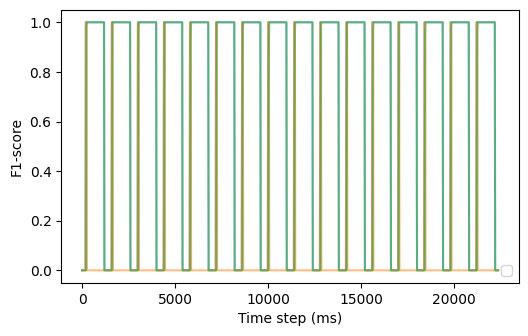

In [5]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.plot(onsets_np, evoked_np, alpha=.5)
ax.plot(onsets_np, mask_np, alpha=.5)
ax.plot(onsets_np, scores_np, alpha=.5)
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("F1-score")
ax.legend(loc='lower right')

if figpath is not None: 
    printfig(fig, 'retrieval', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)

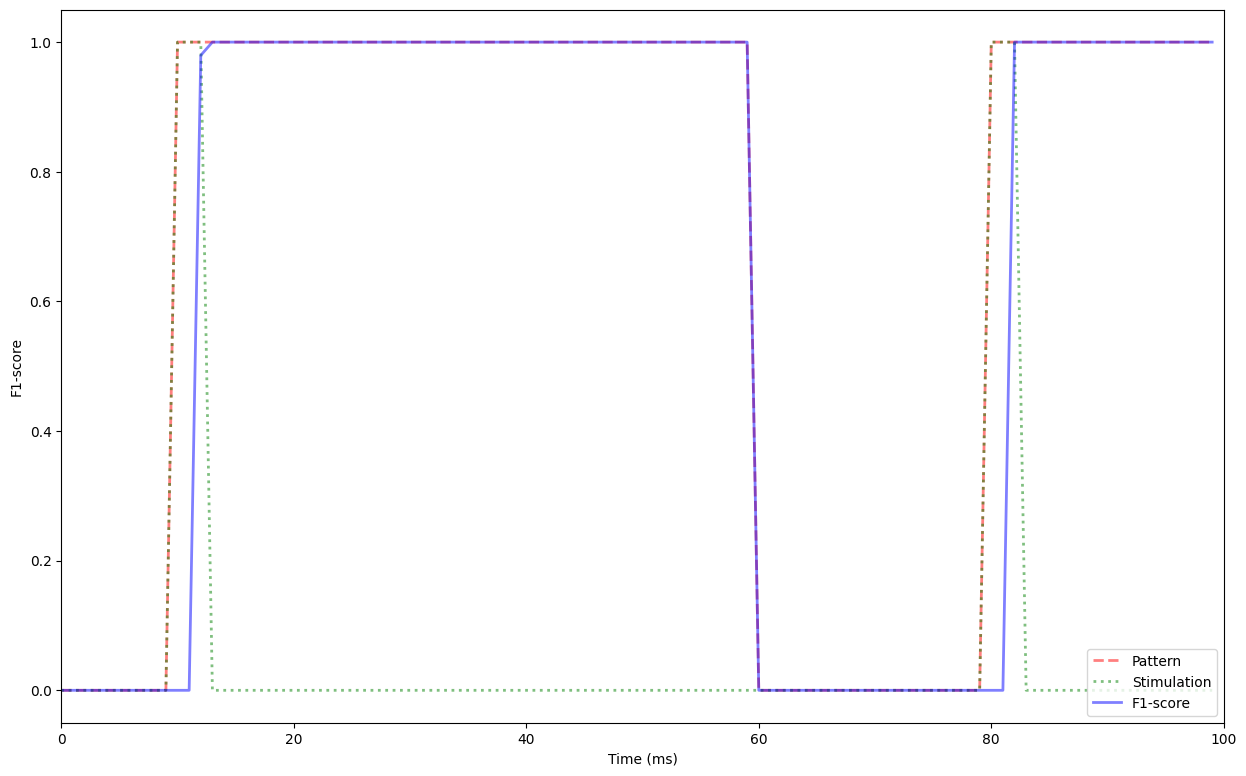

In [6]:
import matplotlib.animation as animation

# Create the figure and axis
fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))

line2, = ax.plot([], [], 'r--', label='Pattern', linewidth=2, alpha=.5)
line3, = ax.plot([], [], 'g:', label='Stimulation', linewidth=2, alpha=.5)
line1, = ax.plot([], [], 'b-', label='F1-score', linewidth=2, alpha=.5)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("F1-score")
ax.legend(loc='lower right')

window_size = 100
total_steps = len(onsets_np)
max_start = total_steps - window_size  # Maximum starting index
y_min = min(scores_np.min(), evoked_np.min(), mask_np.min())
y_max = max(scores_np.max(), evoked_np.max(), mask_np.max())
if y_min == y_max:
    y_min, y_max = y_min - 0.1, y_max + 0.1
y_range = y_max - y_min
ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.05 * y_range)

def animate(frame):
    start_idx = frame
    end_idx = start_idx + window_size
    ax.set_xlim(start_idx, end_idx)
    if end_idx <= total_steps:
        x_data = np.arange(start_idx, end_idx)
        line1.set_data(x_data, scores_np[start_idx:end_idx])
        line2.set_data(x_data, evoked_np[start_idx:end_idx])
        line3.set_data(x_data, mask_np[start_idx:end_idx])
    
    return line1, line2, line3

# Create animation - one frame for each possible window position
anim = animation.FuncAnimation(
    fig, 
    animate, 
    frames=range(0, max_start + 1, 5),  # Step by 5 for smoother animation
    interval=50,  # 50ms between frames (~20 FPS)
    blit=False,
    repeat=True
)

# Save or display
if figpath is not None:
    # Save as gif or mp4
    # anim.save(figpath / 'retrieval_animation.gif', writer='pillow', fps=20)
    anim.save(figpath / 'retrieval.mp4', writer='ffmpeg', fps=10)

### TODO : testing training - growing with num epochs


## TODO: test an overlapping pattern